In [180]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt


In [181]:
df = pd.read_csv(r'D:\Hoc-May\Lam_Bai_Lab\01-Phan-loai\TT-04-Logistic-Regression\heart.csv')
df.info()
print(df.nunique())
print(df.shape)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target  

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [182]:
print(df['ca'].value_counts())
print(df['thal'].value_counts())
df.isnull().sum()
x_vif = df.drop('target',axis =1)

ca
0    578
1    226
2    134
3     69
4     18
Name: count, dtype: int64
thal
2    544
3    410
1     64
0      7
Name: count, dtype: int64


In [183]:
df['ca'] = df['ca'].replace(4, np.nan)
df['thal'] = df['thal'].replace(0, np.nan)
df = df.dropna()
df.shape

(1000, 14)

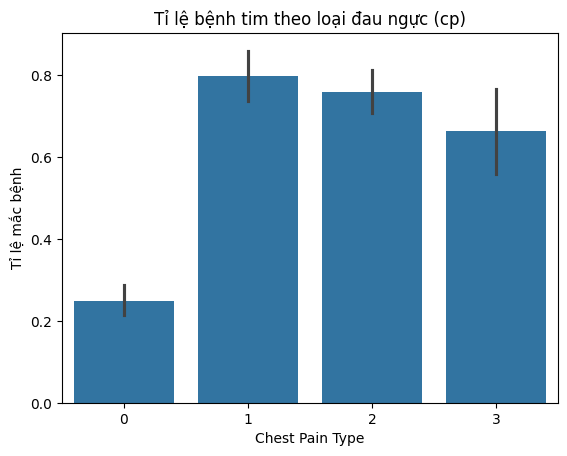

In [184]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=df,
    x='cp',
    y='target'
)

plt.title('Tỉ lệ bệnh tim theo loại đau ngực (cp)')
plt.xlabel('Chest Pain Type')
plt.ylabel('Tỉ lệ mắc bệnh')
plt.show()

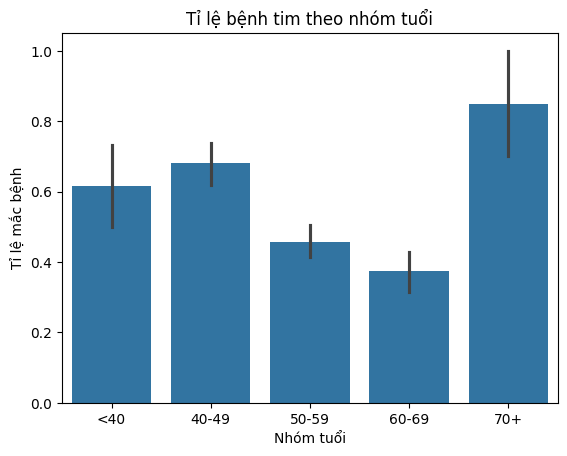

In [185]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 40, 50, 60, 70, 100],
    labels=['<40', '40-49', '50-59', '60-69', '70+']
)

sns.barplot(
    data=df,
    x='age_group',
    y='target'
)

plt.title('Tỉ lệ bệnh tim theo nhóm tuổi')
plt.xlabel('Nhóm tuổi')
plt.ylabel('Tỉ lệ mắc bệnh')
plt.show()

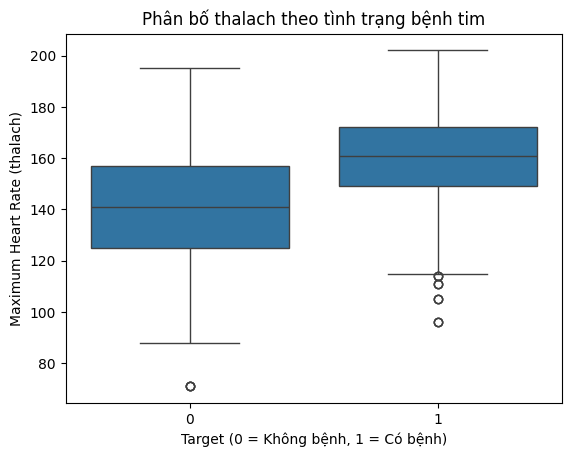

In [186]:
sns.boxplot(
    data=df,
    x='target',
    y='thalach'
)

plt.title('Phân bố thalach theo tình trạng bệnh tim')
plt.xlabel('Target (0 = Không bệnh, 1 = Có bệnh)')
plt.ylabel('Maximum Heart Rate (thalach)')
plt.show()

In [187]:
df = df.drop(columns=['age_group'])
df = df.drop_duplicates()
df = pd.get_dummies(
    df,
    columns = ["cp", "restecg", "slope", "thal"]
)
df.shape

(296, 23)

In [188]:
from sklearn.model_selection import train_test_split

x = df.drop('target',axis = 1)
y = df['target']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)



In [189]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV,StratifiedKFold,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])
param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__solver': ['liblinear', 'lbfgs']
}

grid_search =  GridSearchCV(
    estimator = pipe,
    param_grid = param_grid,
    cv = 5,
    scoring = 'recall',
    n_jobs = 1
)

dummy = DummyClassifier(
    strategy="most_frequent"
)

dummy.fit(x_train, y_train)

grid_search.fit(x_train,y_train)



GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('lr',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=1,
             param_grid={'lr__C': [0.01, 0.1, 1, 10, 100],
                         'lr__solver': ['liblinear', 'lbfgs']},
             scoring='recall')

In [190]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'lr__C': 1, 'lr__solver': 'liblinear'}
0.8713333333333333


In [191]:
from sklearn.metrics import recall_score,classification_report,precision_score

best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
y_pred_train = best_model.predict(x_train)
y_pred_dummy = dummy.predict(x_test)

print('Test recall', recall_score(y_test,y_pred))
print("===== LOGISTIC REGRESSION - TEST =====")
print(classification_report(y_test,y_pred))
print("===== LOGISTIC REGRESSION - TRAIN =====")
print(classification_report(y_train,y_pred_train))
print("===== DUMMY CLASSIFIER - TEST =====")
print(classification_report(y_test, y_pred_dummy))

Test recall 0.9444444444444444
===== LOGISTIC REGRESSION - TEST =====
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        24
           1       0.92      0.94      0.93        36

    accuracy                           0.92        60
   macro avg       0.92      0.91      0.91        60
weighted avg       0.92      0.92      0.92        60

===== LOGISTIC REGRESSION - TRAIN =====
              precision    recall  f1-score   support

           0       0.89      0.82      0.86       112
           1       0.85      0.91      0.88       124

    accuracy                           0.87       236
   macro avg       0.87      0.87      0.87       236
weighted avg       0.87      0.87      0.87       236

===== DUMMY CLASSIFIER - TEST =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        24
           1       0.60      1.00      0.75        36

    accuracy                        

c:\Users\hieum\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hieum\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hieum\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [192]:
scores = cross_val_score(
    best_model,
    x_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)
print("ROC-AUC:", scores.mean())
print("Std:", scores.std())

ROC-AUC: 0.899072463768116
Std: 0.042427962095217035


In [193]:
odds = pd.DataFrame({
    'dac_trung': x_train.columns,
    'he_so_w': best_model.named_steps['lr'].coef_[0],
    'odds_ratio': np.exp(best_model.named_steps['lr'].coef_[0])
}).sort_values('odds_ratio', ascending=False)

odds

,dac_trung,he_so_w,odds_ratio
4,fbs,0.453219,1.573368
5,thalach,0.387038,1.472612
18,slope_2,0.325286,1.384427
12,cp_3,0.317707,1.373974
20,thal_2.0,0.294430,1.342362
11,cp_2,0.276613,1.318656
19,thal_1.0,0.192796,1.212635
0,age,0.127557,1.136049
14,restecg_1,0.077048,1.080094
10,cp_1,-0.036244,0.964405


In [194]:
proba = best_model.predict_proba(x_test)[:, 1]
y_pred = (proba >= 0.53).astype(int)

recall = recall_score(y_test, y_pred)
print("Precision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))
print(f'# Threshold = 0.53 được chọn vì đây là ngưỡng mà Recall bắt đầu đạt ≥ 0.90.\n'
        '# Với threshold này, mô hình ưu tiên phát hiện đúng các ca bệnh,\n'
        '# chấp nhận đánh đổi một phần Precision. Thường sẽ là vậy nhưng ở đây do có sự trùng hợp nên là trường hợp này 2 thằng bằng nhau\n')

Precision: 0.9166666666666666
Recall: 0.9166666666666666
# Threshold = 0.53 được chọn vì đây là ngưỡng mà Recall bắt đầu đạt ≥ 0.90.
# Với threshold này, mô hình ưu tiên phát hiện đúng các ca bệnh,
# chấp nhận đánh đổi một phần Precision. Thường sẽ là vậy nhưng ở đây do có sự trùng hợp nên là trường hợp này 2 thằng bằng nhau



In [195]:
patient = x_test.iloc[[0]]

print(patient)
proba = best_model.predict_proba(patient)[0, 1]

print("Xác suất mắc bệnh:", proba)
prediction = int(proba >= 0.53)

print("Dự đoán:", prediction)
print(f"Đối với bệnh nhân được lựa chọn, mô hình Logistic Regression dự đoán bệnh nhân thuộc nhóm có nguy cơ mắc bệnh tim với xác suất khoảng 94%.\n"
      "Kết quả này vượt qua ngưỡng dự đoán 0.32 được lựa chọn để đảm bảo Recall ≥ 0.90, do đó bệnh nhân được phân loại vào nhóm dương tính.\n"
      "Một số đặc trưng trong hồ sơ bệnh nhân có hệ số Odds Ratio làm tăng hoặc giảm odds mắc bệnh theo mô hình.\n"
      "Tuy nhiên, đây là kết quả dự đoán của mô hình machine learning, không phải chẩn đoán y khoa; quyết định lâm sàng cần dựa trên đánh giá của bác sĩ và các xét nghiệm liên quan.")

     age  sex  trestbps  chol  fbs  thalach  exang  oldpeak   ca   cp_0  ...  \
580   46    1       101   197    1      156      0      0.0  0.0  False  ...   

      cp_3  restecg_0  restecg_1  restecg_2  slope_0  slope_1  slope_2  \
580  False      False       True      False    False    False     True   

     thal_1.0  thal_2.0  thal_3.0  
580     False     False      True  

[1 rows x 22 columns]
Xác suất mắc bệnh: 0.9479792846001874
Dự đoán: 1
Đối với bệnh nhân được lựa chọn, mô hình Logistic Regression dự đoán bệnh nhân thuộc nhóm có nguy cơ mắc bệnh tim với xác suất khoảng 94%.
Kết quả này vượt qua ngưỡng dự đoán 0.32 được lựa chọn để đảm bảo Recall ≥ 0.90, do đó bệnh nhân được phân loại vào nhóm dương tính.
Một số đặc trưng trong hồ sơ bệnh nhân có hệ số Odds Ratio làm tăng hoặc giảm odds mắc bệnh theo mô hình.
Tuy nhiên, đây là kết quả dự đoán của mô hình machine learning, không phải chẩn đoán y khoa; quyết định lâm sàng cần dựa trên đánh giá của bác sĩ và các xét nghiệm liên

In [196]:
print(x.dtypes)

age            int64
sex            int64
trestbps       int64
chol           int64
fbs            int64
thalach        int64
exang          int64
oldpeak      float64
ca           float64
cp_0            bool
cp_1            bool
cp_2            bool
cp_3            bool
restecg_0       bool
restecg_1       bool
restecg_2       bool
slope_0         bool
slope_1         bool
slope_2         bool
thal_1.0        bool
thal_2.0        bool
thal_3.0        bool
dtype: object


In [197]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif = pd.DataFrame()

vif["dac_trung"] = x_vif.columns

vif["VIF"] = [
    variance_inflation_factor(x_vif.values, i)
    for i in range(x_vif.shape[1])
]

vif = vif.sort_values("VIF", ascending=False)

vif

,dac_trung,VIF
3,trestbps,57.953085
7,thalach,42.598372
0,age,38.699830
4,chol,26.185961
12,thal,16.724068
10,slope,9.854424
1,sex,3.613725
9,oldpeak,3.117289
2,cp,2.376553
8,exang,2.073879


In [199]:
vif[vif["VIF"] > 10]
print('Kết quả VIF cho thấy trestbps, thalach, age, chol và thal có VIF > 10, trong đó trestbps có mức đa cộng tuyến cao nhất (VIF ≈ 57.95).')

Kết quả VIF cho thấy trestbps, thalach, age, chol và thal có VIF > 10, trong đó trestbps có mức đa cộng tuyến cao nhất (VIF ≈ 57.95).
